In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('Maternal Health Risk Data Set.csv')
print(df.shape)

(1014, 7)


In [5]:
x =  df.drop(columns='RiskLevel')
y = df['RiskLevel']

smote = SMOTE(random_state = 42)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify=y)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

print(f"Training set after smote: {x_train_sm.shape}")
print(f"test set untouched: {x_test.shape} ")
print(pd.Series(y_train_sm).value_counts())

Training set after smote: (975, 6)
test set untouched: (203, 6) 
RiskLevel
high risk    325
low risk     325
mid risk     325
Name: count, dtype: int64


In [11]:
#encoding valuues for Risk Level to numerical values, since XG Boost requires numerical lables
le = LabelEncoder()
y_train_enc =  le.fit_transform(y_train_sm)
y_test_enc = le.fit_transform(y_test)

print("Class Mapping")
for i, cls in enumerate(le.classes_):
    print(f"{i}->{cls}")

Class Mapping
0->high risk
1->low risk
2->mid risk


In [14]:
#wrapping each model in a pipeline that includes a standard scaler first to prevent data leakage 
pipelines = {
    'Logistic Regression': Pipeline([('Scaler', StandardScaler()),('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Random Forest': Pipeline([('Scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'XGBoost': Pipeline([('Scaler', StandardScaler()), ('clf', XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0))])
}

In [16]:
#ccross validation on the training data to know how much each model is stable across differebt subsets of training data 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, x_train_sm, y_train_enc, cv=cv, scoring='f1_weighted')
    results[name] = scores
    print(f"{name}")
    print(f"CV F1 scores: {scores.round(4)}")
    print(f"Mean: {scores.mean():.4f} Std: {scores.std():.4f}\n")

Logistic Regression
CV F1 scores: [0.5882 0.6139 0.6418 0.5836 0.635 ]
Mean: 0.6125 Std: 0.0236

Random Forest
CV F1 scores: [0.8504 0.8269 0.7902 0.8449 0.8664]
Mean: 0.8358 Std: 0.0261

XGBoost
CV F1 scores: [0.8558 0.8367 0.8008 0.8341 0.8667]
Mean: 0.8388 Std: 0.0225



In [19]:
#training on the full training set
for name, pipe in pipelines.items():
    pipe.fit(x_train_sm, y_train_enc)
    y_pred = pipe.predict(x_test)
    y_prob =  pipe.predict_proba(x_test)

    print(f"{name} - Test set Results")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

    auc = roc_auc_score(y_test_enc, y_prob, multi_class='ovr', average='weighted')
    print(f"Weighted AUC-ROC: {auc:.4f}\n")

Logistic Regression - Test set Results
              precision    recall  f1-score   support

   high risk       0.74      0.76      0.75        55
    low risk       0.65      0.77      0.70        81
    mid risk       0.45      0.34      0.39        67

    accuracy                           0.63       203
   macro avg       0.61      0.62      0.61       203
weighted avg       0.61      0.63      0.61       203

Weighted AUC-ROC: 0.7832

Random Forest - Test set Results
              precision    recall  f1-score   support

   high risk       0.88      0.93      0.90        55
    low risk       0.87      0.80      0.83        81
    mid risk       0.76      0.79      0.77        67

    accuracy                           0.83       203
   macro avg       0.83      0.84      0.84       203
weighted avg       0.83      0.83      0.83       203

Weighted AUC-ROC: 0.9430

XGBoost - Test set Results
              precision    recall  f1-score   support

   high risk       0.88      0.9

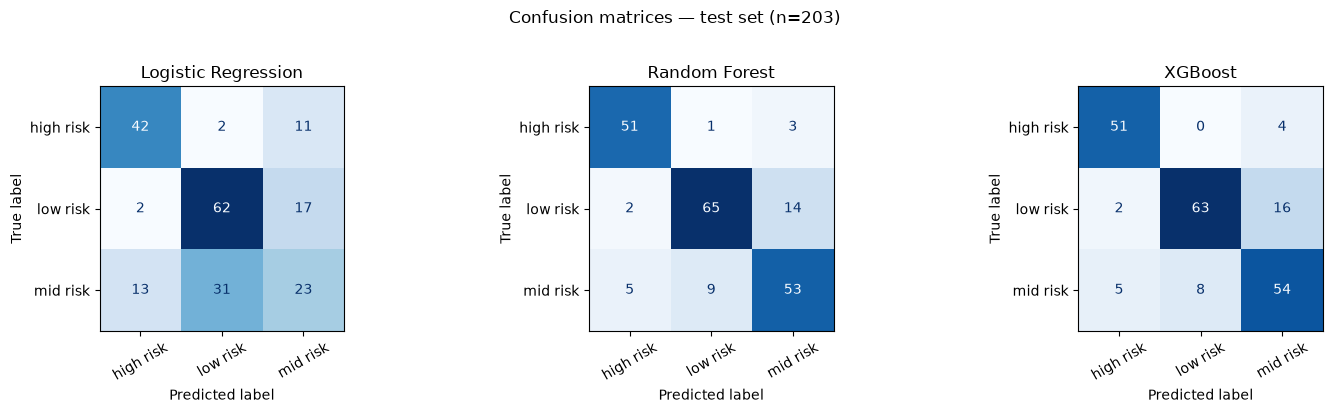

In [21]:
#confusion matrix 
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, (name, pipe) in zip(axes, pipelines.items()):
    y_pred = pipe.predict(x_test)
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
    ax.tick_params(axis='x', rotation = 30)

plt.suptitle('Confusion matrices — test set (n=203)', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


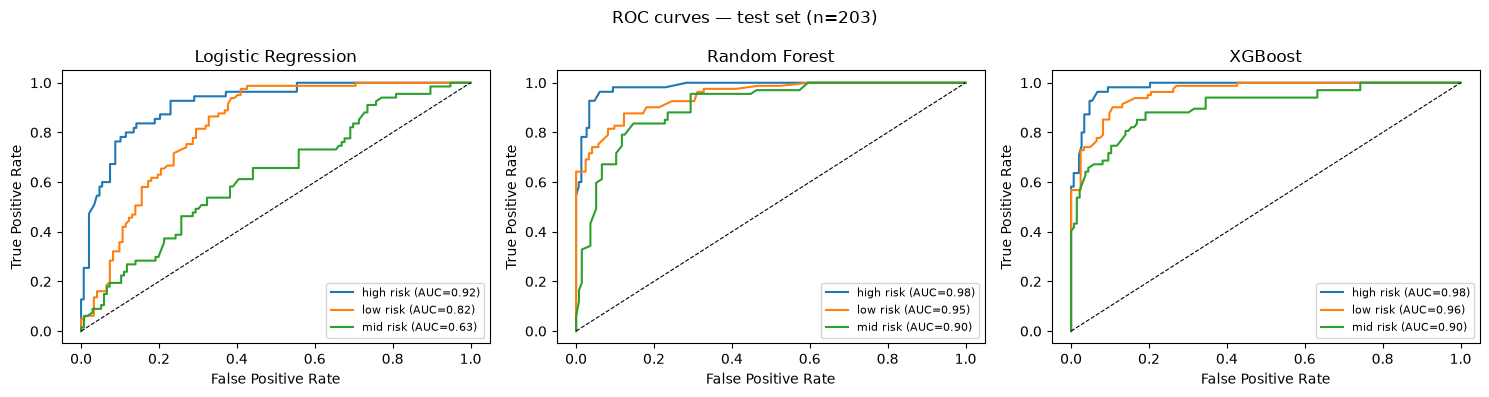

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = le.classes_
y_test_bin = label_binarize(y_test_enc, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#6366F1', '#10B981', '#F59E0B']

for ax, (name, pipe), color in zip(axes, pipelines.items(), colors):
    y_prob = pipe.predict_proba(x_test)
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.2f})')
    ax.plot([0,1],[0,1],'k--', linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)

plt.suptitle('ROC curves — test set (n=203)')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
import joblib

best_model_name = 'XGBoost'
best_pipe = pipelines[best_model_name]

joblib.dump(best_pipe, 'model.joblib')
joblib.dump(le, 'label_encoder.joblib')

print(f"Saved: {best_model_name} pipeline → model.joblib")
print(f"Saved: LabelEncoder → label_encoder.joblib")

Saved: XGBoost pipeline → model.joblib
Saved: LabelEncoder → label_encoder.joblib


In [27]:
import shap

xgb_model = pipelines['XGBoost'].named_steps['clf']
scaler = pipelines['XGBoost'].named_steps['Scaler']
x_test_scaled = scaler.transform(x_test)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_test_scaled)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Classes: {le.classes_}")

SHAP values shape: (203, 6, 3)
Classes: ['high risk' 'low risk' 'mid risk']


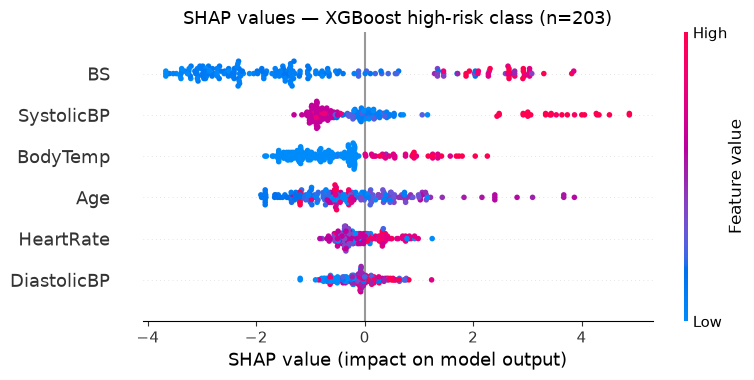

Saved.


In [28]:
# index 0 = high risk (from your le.classes_ output)
HIGH_RISK_IDX = 0

shap_high = shap_values[:, :, HIGH_RISK_IDX]

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_high,
    x_test_scaled,
    feature_names=x_test.columns.tolist(),
    plot_type='dot',
    show=False,
    max_display=6
)
plt.title('SHAP values — XGBoost high-risk class (n=203)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=300,bbox_inches='tight')
plt.show()
print("Saved.")

In [29]:
mean_shap = np.abs(shap_high).mean(axis=0)
feature_names = x_test.columns.tolist()

shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP value|': mean_shap.round(4)
}).sort_values('Mean |SHAP value|', ascending=False).reset_index(drop=True)

print("Feature importance ranking (high-risk class):")
print(shap_df.to_string(index=False))

Feature importance ranking (high-risk class):
    Feature  Mean |SHAP value|
         BS             2.0790
 SystolicBP             0.9358
   BodyTemp             0.8773
        Age             0.8592
  HeartRate             0.3349
DiastolicBP             0.3109


In [30]:
xgb_probs = pipelines['XGBoost'].predict_proba(x_test)
most_high_risk_idx = xgb_probs[:, HIGH_RISK_IDX].argmax()

print(f"Patient index: {most_high_risk_idx}")
print(f"Predicted probabilities: {xgb_probs[most_high_risk_idx].round(3)}")
print(f"Predicted class: {le.classes_[pipelines['XGBoost'].predict(x_test)[most_high_risk_idx]]}")
print(f"Actual class: {y_test.iloc[most_high_risk_idx]}")
print(f"\nPatient feature values:")
print(x_test.iloc[most_high_risk_idx])

Patient index: 22
Predicted probabilities: [1. 0. 0.]
Predicted class: high risk
Actual class: high risk

Patient feature values:
Age             30.0
SystolicBP     140.0
DiastolicBP    100.0
BS              15.0
BodyTemp        98.0
HeartRate       70.0
Name: 113, dtype: float64


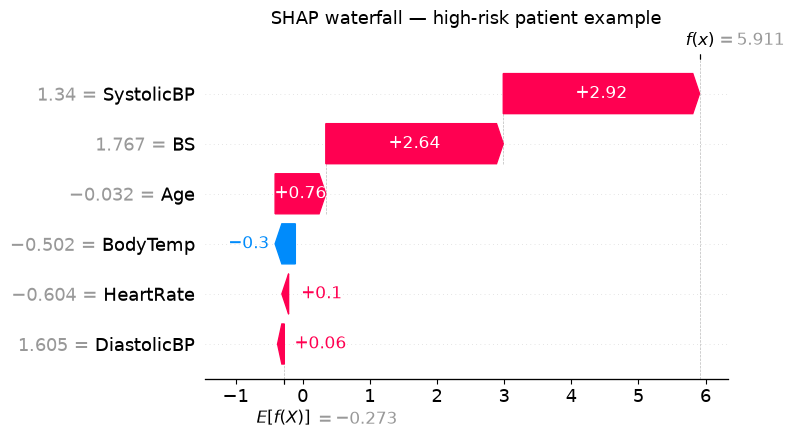

Saved.


In [31]:
explanation = shap.Explanation(
    values=shap_high[most_high_risk_idx],
    base_values=explainer.expected_value[HIGH_RISK_IDX],
    data=x_test_scaled[most_high_risk_idx],
    feature_names=x_test.columns.tolist()
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(explanation, show=False)
plt.title(f'SHAP waterfall — high-risk patient example', fontsize=13)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")